In [137]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df_train = pd.read_excel('C:\\Users\\Користувач\\Desktop\\Project\\materials\\labeled_df.xlsx')

## Overview

In [96]:
df_train.head()

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match,Manual_Category,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_1,716.0,2.97,2021-12-09,2.0,По информационному праву Токарева Ксения Серге...,2021-12-09,2021.0,3.0,neutral,negative,0.0,negative,1.0,0.0,0.0,0.0,0.0
1,University_1,716.0,2.97,2021-09-29,3.0,"Всем добрый день!Хороший университет,но почему...",2021-09-29,2021.0,4.0,positive,neutral,0.0,neutral,NaN,NaN,NaN,NaN,NaN
2,University_1,716.0,2.97,2021-08-25,1.0,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021.0,3.0,neutral,negative,0.0,negative,0.0,1.0,0.0,0.0,0.0
3,University_1,716.0,2.97,2020-06-01,4.0,нормальный университет все прошло хорошо.Кто х...,2020-06-01,2020.0,1.0,negative,positive,0.0,positive,NaN,NaN,NaN,NaN,NaN
4,University_1,716.0,2.97,2020-04-07,5.0,"Читая ваши отзывы про другие кафедры, такое чу...",2020-04-07,2020.0,1.0,negative,positive,0.0,positive,NaN,NaN,NaN,NaN,NaN


In [97]:
df_train.shape

(1751, 18)

In [98]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1751 entries, 0 to 1750
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              1751 non-null   object 
 1   Reviews Count                1675 non-null   float64
 2   Average Rating               1675 non-null   float64
 3   Review Date                  1751 non-null   object 
 4   Review Rating                1675 non-null   float64
 5   Review Text                  1751 non-null   object 
 6   Timestamp                    1675 non-null   object 
 7   Year                         1675 non-null   float64
 8   bert_sentiment               1675 non-null   float64
 9   Sentiment_Category_BERT      1675 non-null   object 
 10  Star_Sentiment_Category      1675 non-null   object 
 11  Match                        1675 non-null   float64
 12  Manual_Category              1749 non-null   object 
 13  Attitude_Towards_S

In [99]:
df_train[df_train['Reviews Count'].isnull() > 0]

,University Name,Reviews Count,Average Rating,Review Date,Review Rating,Review Text,Timestamp,Year,bert_sentiment,Sentiment_Category_BERT,Star_Sentiment_Category,Match,Manual_Category,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
1675,University_4,NaN,NaN,2025-06-16 00:00:00,NaN,"Не розумію, чому люди фанатіють від цього вузу...",NaN,NaN,NaN,NaN,NaN,NaN,negative,1.0,0.0,1.0,0.0,0.0
1676,University_4,NaN,NaN,2024-12-16 00:00:00,NaN,"10 градусів в аудиторіях, від преподів 0 поваги",NaN,NaN,NaN,NaN,NaN,NaN,negative,1.0,1.0,0.0,0.0,0.0
1677,University_4,NaN,NaN,2024-12-16 00:00:00,NaN,Дуже холодно на парах,NaN,NaN,NaN,NaN,NaN,NaN,negative,0.0,1.0,0.0,0.0,0.0
1678,University_4,NaN,NaN,2023-09-16 00:00:00,NaN,"Найбезвідповідальніший університет в Україні, ...",NaN,NaN,NaN,NaN,NaN,NaN,negative,0.0,0.0,0.0,1.0,0.0
1679,University_4,NaN,NaN,2025-06-16 00:00:00,NaN,Шарага одним словом. Купа нікому не потрібних ...,NaN,NaN,NaN,NaN,NaN,NaN,negative,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1746,University_1,NaN,NaN,2025-04-16 00:00:00,NaN,Ех… І з чого б почати? Формально мінімальна оц...,NaN,NaN,NaN,NaN,NaN,NaN,negative,0.0,1.0,0.0,0.0,0.0
1747,University_1,NaN,NaN,2025-02-16 00:00:00,NaN,Це найгірший університет у світі. Будь-якому і...,NaN,NaN,NaN,NaN,NaN,NaN,negative,0.0,0.0,0.0,1.0,0.0
1748,University_1,NaN,NaN,2024-11-16 00:00:00,NaN,"Взятки беруть, топ унік. За 400 долларів можеш...",NaN,NaN,NaN,NaN,NaN,NaN,negative,0.0,0.0,1.0,0.0,0.0
1749,University_1,NaN,NaN,2024-09-16 00:00:00,NaN,Назва ВНЗ не відповідає дійсності -авіацією ту...,NaN,NaN,NaN,NaN,NaN,NaN,negative,0.0,0.0,0.0,0.0,1.0


### Feature Selection for Model Training

The model is trained using only the following columns:
- **University Name**
- **Review Date**
- **Review Text**
- **Attitude_Towards_Students**
- **Campus_conditions**
- **Corruption**
- **Academic_Process_Management**
- **Education_Quality**

Since the remaining columns are not used for feature construction, missing values in those columns do not require preprocessing. They do not affect the training process or the model’s predictive performance.

In [100]:
selected_columns = [
    'University Name',
    'Review Text',
    'Manual_Category',
    'Attitude_Towards_Students',
    'Campus_conditions',
    'Corruption',
    'Academic_Process_Management',
    'Education_Quality'
]

df_train = df_train[selected_columns]

In [101]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1751 entries, 0 to 1750
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              1751 non-null   object 
 1   Review Text                  1751 non-null   object 
 2   Manual_Category              1749 non-null   object 
 3   Attitude_Towards_Students    522 non-null    float64
 4   Campus_conditions            521 non-null    float64
 5   Corruption                   521 non-null    float64
 6   Academic_Process_Management  521 non-null    float64
 7   Education_Quality            521 non-null    float64
dtypes: float64(5), object(3)
memory usage: 109.6+ KB


In [102]:
# Replace NaN with 0 to include positive and neutral reviews in training
cols = [
    'Attitude_Towards_Students',
    'Campus_conditions',
    'Corruption',
    'Academic_Process_Management',
    'Education_Quality'
]

mask = df_train['Manual_Category'].isin(['positive', 'neutral'])

df_train.loc[mask, cols] = df_train.loc[mask, cols].fillna(0)

In [104]:
df_train.isnull().sum()

University Name                0
Review Text                    0
Manual_Category                2
Attitude_Towards_Students      0
Campus_conditions              0
Corruption                     0
Academic_Process_Management    0
Education_Quality              0
dtype: int64

In [105]:
df_train = df_train.dropna(subset=['Manual_Category'])

In [106]:
df_train.isnull().sum()

University Name                0
Review Text                    0
Manual_Category                0
Attitude_Towards_Students      0
Campus_conditions              0
Corruption                     0
Academic_Process_Management    0
Education_Quality              0
dtype: int64

In [107]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1749 entries, 0 to 1750
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              1749 non-null   object 
 1   Review Text                  1749 non-null   object 
 2   Manual_Category              1749 non-null   object 
 3   Attitude_Towards_Students    1749 non-null   float64
 4   Campus_conditions            1749 non-null   float64
 5   Corruption                   1749 non-null   float64
 6   Academic_Process_Management  1749 non-null   float64
 7   Education_Quality            1749 non-null   float64
dtypes: float64(5), object(3)
memory usage: 123.0+ KB


In [109]:
df_train['University Name'].nunique(), df_train['Review Text'].nunique()

(21, 1740)

In [110]:
df_train[df_train['Review Text'].duplicated(keep=False)]

,University Name,Review Text,Manual_Category,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
7,University_1,"Шановні вступники, якщо ви хочете зберегти сво...",negative,0.0,1.0,0.0,0.0,1.0
85,University_6,"Говорят, учиться тут сложновато. Преподаватели...",positive,0.0,0.0,0.0,0.0,0.0
177,University_13,Норм,positive,0.0,0.0,0.0,0.0,0.0
183,University_13,"Так себек, 5 год впустую",positive,0.0,0.0,0.0,0.0,0.0
184,University_13,"Так себек, 5 год впустую",positive,0.0,0.0,0.0,0.0,0.0
187,University_13,Норм,positive,0.0,0.0,0.0,0.0,0.0
673,University_6,"Говорят, учиться тут сложновато. Преподаватели...",positive,0.0,0.0,0.0,0.0,0.0
1011,University_10,Норм,neutral,0.0,0.0,0.0,0.0,0.0
1020,University_7,Закінчила з відзнакою у 2015 році :)\nКорупції...,positive,0.0,0.0,0.0,0.0,0.0
1021,University_7,Закінчила з відзнакою у 2015 році :)\nКорупції...,positive,0.0,0.0,0.0,0.0,0.0


In [111]:
df_train = df_train.drop_duplicates(subset=['Review Text']) # Remove duplicate rows from the dataset.
# This is important to prevent data leakage, especially because we will be using cross-validation.

In [112]:
df_train.duplicated().sum()

np.int64(0)

In [126]:
df_train['University Name'].describe()

count             1740
unique              21
top       University_2
freq               223
Name: University Name, dtype: object

In [130]:
df_train['University Name'].value_counts().sort_values(ascending=False)

University Name
University_2     223
University_1     185
University_4     160
University_6     155
University_7     114
University_3     109
University_8      97
University_5      94
University_9      86
University_10     81
University_12     68
University_11     66
University_14     50
University_16     42
University_17     38
University_13     36
University_15     35
University_18     33
University_19     33
University_20     21
University_21     14
Name: count, dtype: int64

## Text length analysis

In [119]:

def preprocess_text_for_embeddings(text):
    """
    Minimal preprocessing before generating Sentence Embeddings.
    - Keeps casing and punctuation, including hyphens and apostrophes.
    - Replaces censored words (***** ) with a placeholder [CENSORED].
    - Removes extra spaces.
    - Ensures text is a clean string suitable for embedding models.
    """
    if not isinstance(text, str):
        return ""
    
    # Replace censored words with a placeholder
    text = text.replace("*****", "[CENSORED]")
    
    # Remove control characters and weird invisible symbols
    text = re.sub(r"[\x00-\x1f\x7f]", " ", text)
    
    # Fix glued words after punctuation, e.g., "хорошо.Кто" -> "хорошо. Кто"
    text = re.sub(r"([.!?])([А-Яа-яA-Za-z0-9])", r"\1 \2", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [120]:
df_train["Cleaned_Text"] = df_train["Review Text"].apply(preprocess_text_for_embeddings) 

In [121]:
df_train.head()

,University Name,Review Text,Manual_Category,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text
0,University_1,По информационному праву Токарева Ксения Серге...,negative,1.0,0.0,0.0,0.0,0.0,По информационному праву Токарева Ксения Серге...
1,University_1,"Всем добрый день!Хороший университет,но почему...",neutral,0.0,0.0,0.0,0.0,0.0,"Всем добрый день! Хороший университет,но почем..."
2,University_1,Людоньки це *****. Моя дочку поселили в кімнат...,negative,0.0,1.0,0.0,0.0,0.0,Людоньки це [CENSORED]. Моя дочку поселили в к...
3,University_1,нормальный университет все прошло хорошо.Кто х...,positive,0.0,0.0,0.0,0.0,0.0,нормальный университет все прошло хорошо. Кто ...
4,University_1,"Читая ваши отзывы про другие кафедры, такое чу...",positive,0.0,0.0,0.0,0.0,0.0,"Читая ваши отзывы про другие кафедры, такое чу..."


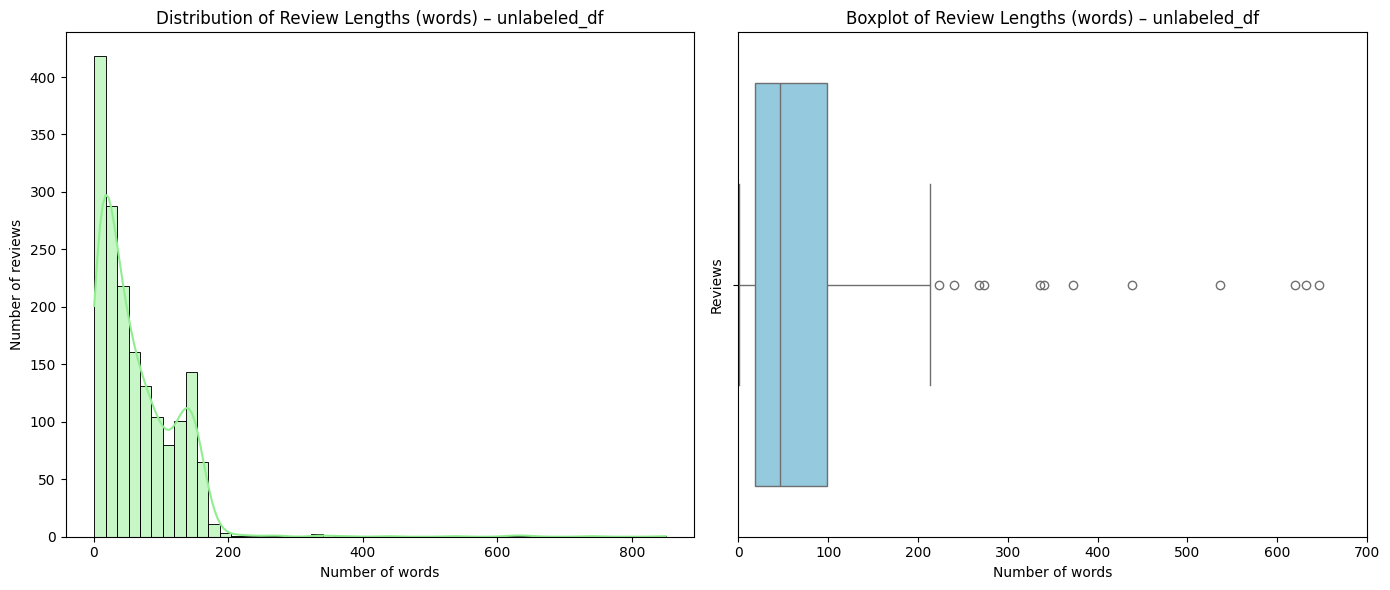

In [139]:
# Define maximum word count threshold (focus on reviews with <= 220 words)
max_words = 1000

# Compute word counts directly from text
word_lengths = df_train["Cleaned_Text"].str.split().str.len()

# Filter reviews that fall within the main range
main_df = df_train[word_lengths <= max_words]

plt.figure(figsize=(14,6))

# 1️⃣ Histogram + KDE for the main group of reviews
plt.subplot(1,2,1)
sns.histplot(word_lengths[word_lengths <= max_words], bins=50, kde=True, color="lightgreen")
plt.title("Distribution of Review Lengths (words) – unlabeled_df")
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")

# 2️⃣ Boxplot for the full dataset to detect outliers
plt.subplot(1,2,2)
sns.boxplot(x=word_lengths, color="skyblue")
plt.title("Boxplot of Review Lengths (words) – unlabeled_df")
plt.xlabel("Number of words")
plt.ylabel("Reviews")
plt.xlim(0, 700)  # adjust to see the long tail

plt.tight_layout()
plt.show()

In [140]:
# Truncate reviews to a maximum number of words (e.g., 200)
max_words_truncate = 200

def truncate_text(text, max_words=max_words_truncate):
    """
    Truncate a text to a maximum number of words.
    """
    if not isinstance(text, str):
        return ""
    words = text.split()
    if len(words) > max_words:
        words = words[:max_words]  # keep only the first max_words
    return " ".join(words)

# Apply truncation to the Cleaned_Text column
df_train["Cleaned_Text_Truncated"] = df_train["Cleaned_Text"].apply(lambda x: truncate_text(x))